STEPS TO WORK WITH ANY PROJECT. (Standard EDA and Pre-processing workflow)
--------------------------
1. Load Dataset
2. Check Shape
3. Check Missing Values
4. Handle Missing Values
5. Check Data Types
6. Fix Incorrect Data Types
7. Statistical Summary
8. Check Duplicate Records
9. Separate Numerical & Categorical Columns

-------------------------
Exploratory Data Analysis
-------------------------
10. Univariate Analysis
11. Bivariate Analysis
12. Multivariate Analysis
13. Correlation Analysis
14. Outlier Detection & Handling

-------------------------
Feature Preparation
-------------------------
15. Feature Engineering (if needed)
16. Feature Encoding
17. Feature Scaling (if needed)
18. Feature Selection (if needed)
19. Dimensionality Reduction (PCA, LDA, t-SNE, UMAP if needed)

-------------------------
Machine Learning
-------------------------
20. Train-Test Split
21. Model Building
22. Hyperparameter Tuning
23. Model Evaluation
24. Model Deployment (optional)

In [1]:
%pip install seaborn

In [2]:
import numpy as np # Python numerical algebra package
import pandas as pd # For working with data frames
from matplotlib import pyplot as plt # For plotting
import seaborn as sns # Another package for plotting
import statsmodels.api as sm #Package for statistical modeling
import scipy.stats as stats # Another package for statistical modeling
from sklearn.preprocessing import LabelEncoder #Python package for machine learning models
import copy

In [3]:
sns.set() # Setting the default  seaborn stype for our plots

In [4]:
#Reading the data into the notebook
df = pd.read_csv('insurance-data.csv') # Reading the data as DataFrame
df.head() #Checking the first 5 rows

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0.0,yes,southwest,16884.92400
1,18,male,33.770,1.0,no,southeast,1725.55230
2,28,male,33.000,3.0,no,southeast,4449.46200
3,33,male,22.705,0.0,no,northwest,21984.47061
4,32,male,28.880,0.0,no,northwest,3866.85520


In [5]:
df.shape

(1339, 7)

In [6]:
# Check for the missing data - STEP  - DATA CLEANING
df.isnull().sum()  # here we have 6 missing values

age         0
sex         1
bmi         1
children    1
smoker      1
region      1
charges     1
dtype: int64

In [7]:
df.isnull().sum().sum() # Verify the missing values

np.int64(6)

In [8]:
# Now first we need to find the missing records and need to handle them
df[df.isnull().any(axis=1)] # Here axis =1 means check row by row and Then it will return all the rows with atleast 1 missing value

,age,sex,bmi,children,smoker,region,charges
1338,✕Merlin,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# As we can see there is only 1 row with the missing values so we can drop this row
df = df.dropna() # To drop all the rows having missing value

In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
# NOW WE COME TO THE NEXT STEP 2 - EDA (Exploratory Data Analysis)
df.info() #Check the dataset structure

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   str    
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   float64
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(3), str(4)
memory usage: 52.3 KB


In [12]:
df.describe() #Generate statistical summary - But
# here we can see that It doesn't give us the stat summary for the 
# columns age. Also, we can convert the types of age,sex,smoker to interger - Like representing male as 0 and female as 1 
# So, it is easy for us and also for the model to handle the numerical data

,bmi,children,charges
count,1338.000000,1338.000000,1338.000000
mean,30.663397,1.094918,13270.422265
std,6.098187,1.205493,12110.011237
min,15.960000,0.000000,1121.873900
25%,26.296250,0.000000,4740.287150
50%,30.400000,1.000000,9382.033000
75%,34.693750,2.000000,16639.912515
max,53.130000,5.000000,63770.428010


In [13]:
# Inverstigating different varables
df['sex'].value_counts() # No. of males and females in the dataset

sex
male      676
female    662
Name: count, dtype: int64

In [14]:
df['children'].value_counts().sort_values() # Distribution of no. of children per person

children
5.0     18
4.0     25
3.0    157
2.0    240
1.0    324
0.0    574
Name: count, dtype: int64

In [15]:
df['age'].value_counts().sort_values() # Age distribution

age
64    22
60    23
61    23
63    23
62    23
39    25
58    25
36    25
38    25
35    25
59    25
37    25
33    26
32    26
55    26
34    26
56    26
57    26
40    27
42    27
29    27
44    27
43    27
41    27
31    27
30    27
25    28
23    28
27    28
22    28
28    28
24    28
21    28
53    28
54    28
49    28
26    28
50    29
51    29
47    29
45    29
20    29
48    29
52    29
46    29
19    68
18    69
Name: count, dtype: int64

In [16]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [17]:
# Data Cleaning - Converting the Categorical features into numerical units - But they still are categorical features, we just change the way of representation 
clean_data = {
    'sex':{'male': 0 ,'female':1},
    'smoker': {'no':0 ,'yes':1},
    'region': {'northwest': 0,'northeast':1,'southeast':2,'southwest':3}
}
df_clean= df.copy()
df_clean.replace(clean_data,inplace = True)
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0.0,1,3,16884.92400
1,18,0,33.770,1.0,0,2,1725.55230
2,28,0,33.000,3.0,0,2,4449.46200
3,33,0,22.705,0.0,0,0,21984.47061
4,32,0,28.880,0.0,0,0,3866.85520


In [18]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   str    
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   float64
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(3), object(3), str(1)
memory usage: 52.3+ KB


In [19]:
# As age is string so we are converting it to Int64
# This converts the column to a numeric type. Pandas will infer whether it should be int64 or float64.
df_clean['age']= pd.to_numeric(df_clean['age'])
# df_clean["age"] = df_clean["age"].astype("int64") # we can also do this thing- But it only converts all the thing to integer only

In [20]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   float64
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 57.6+ KB


In [21]:
df_clean.describe().T # Now all the params are numeric (.T) is for for readable

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [22]:
# And now checking for the duplicates 
df_clean.duplicated().sum() # This will give you the no. of duplicated rows

np.int64(1)

In [23]:
df_clean = df_clean.drop_duplicates() # Handling the duplicates

In [24]:
df_clean.duplicated().sum() # verifying 

np.int64(0)

In [25]:
df_clean_copy = df_clean.copy() # This copy is only for testing things so that whenever df_clean changes and we need to revert it, then we can make so

In [26]:
# STEP - Seperate Numerical and Categorical Columns - This makes plotting much easier later.
numerical_cols = df_clean.select_dtypes(include=['int32','int64','float64']).columns
categorical_cols = df_clean.select_dtypes(include=['object','category']).columns

print("Numerical Columns")
print(numerical_cols)

print()

print("Categorical Columns")
print(categorical_cols)

Numerical Columns
Index(['age', 'bmi', 'children', 'charges'], dtype='str')

Categorical Columns
Index(['sex', 'smoker', 'region'], dtype='str')


In [27]:
# STEP ===> Univariate Analysis - For Single Variable
# 1. Mean, Median, Standard Deviation, Variance & Skewness
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


In [28]:
# 2. Skewness
df_clean[numerical_cols].skew()

age         0.054781
bmi         0.283914
children    0.937421
charges     1.515391
dtype: float64

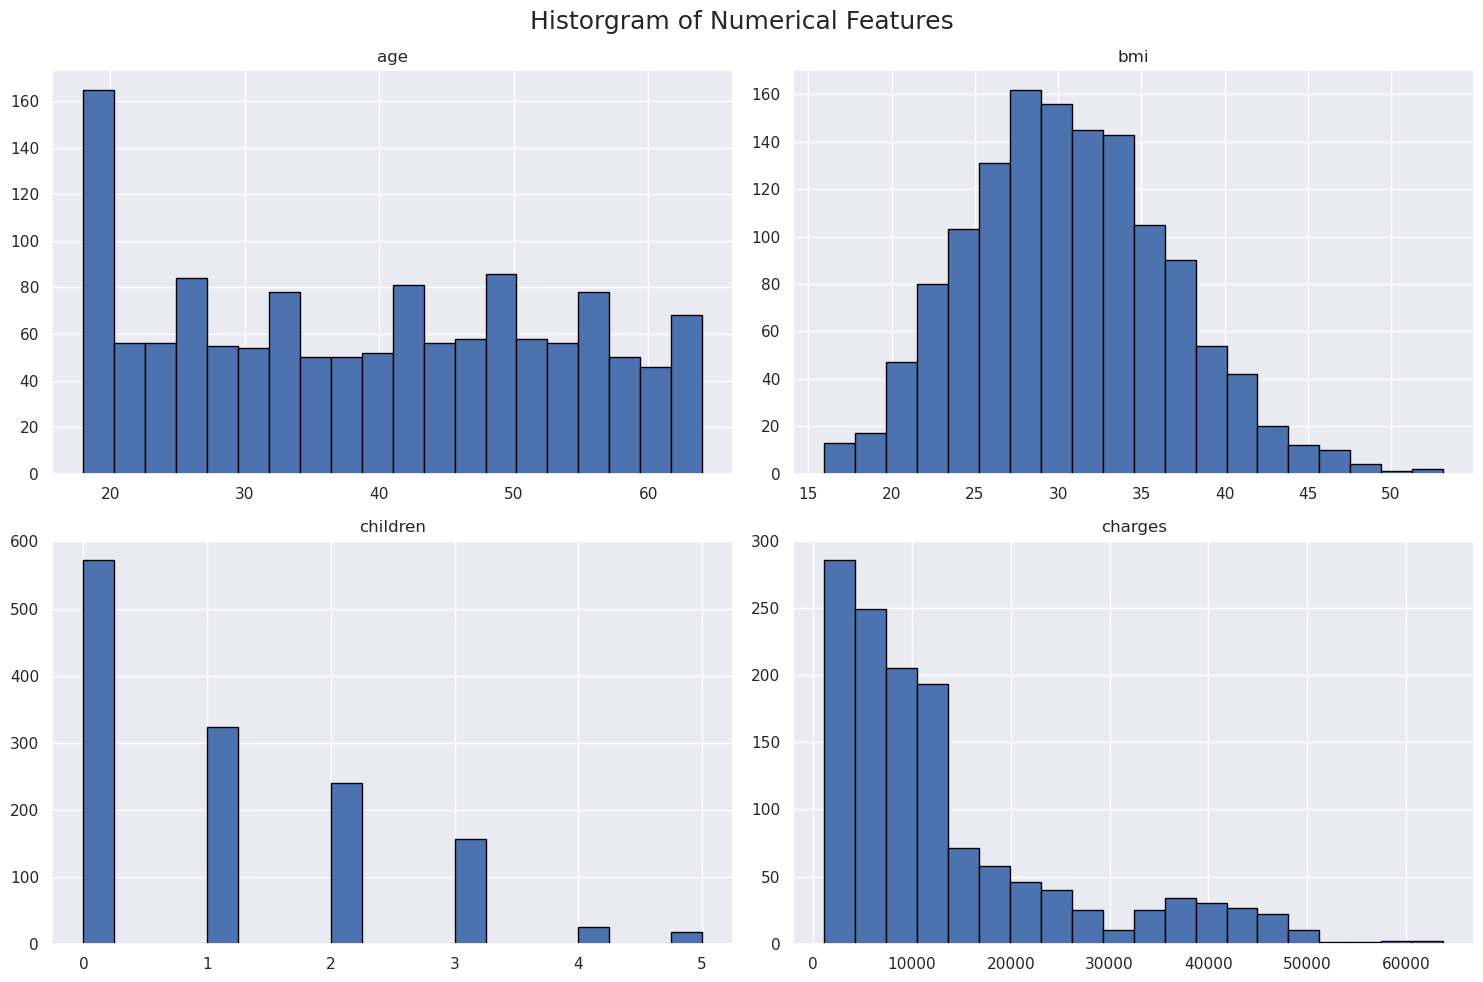

In [29]:
# 3. Histograms for ALL Numerical Features
df_clean[numerical_cols].hist(
    figsize=(15,10),
    bins= 20,
    edgecolor='black'
)
plt.suptitle("Historgram of Numerical Features",fontsize=18)
plt.tight_layout()
plt.show()

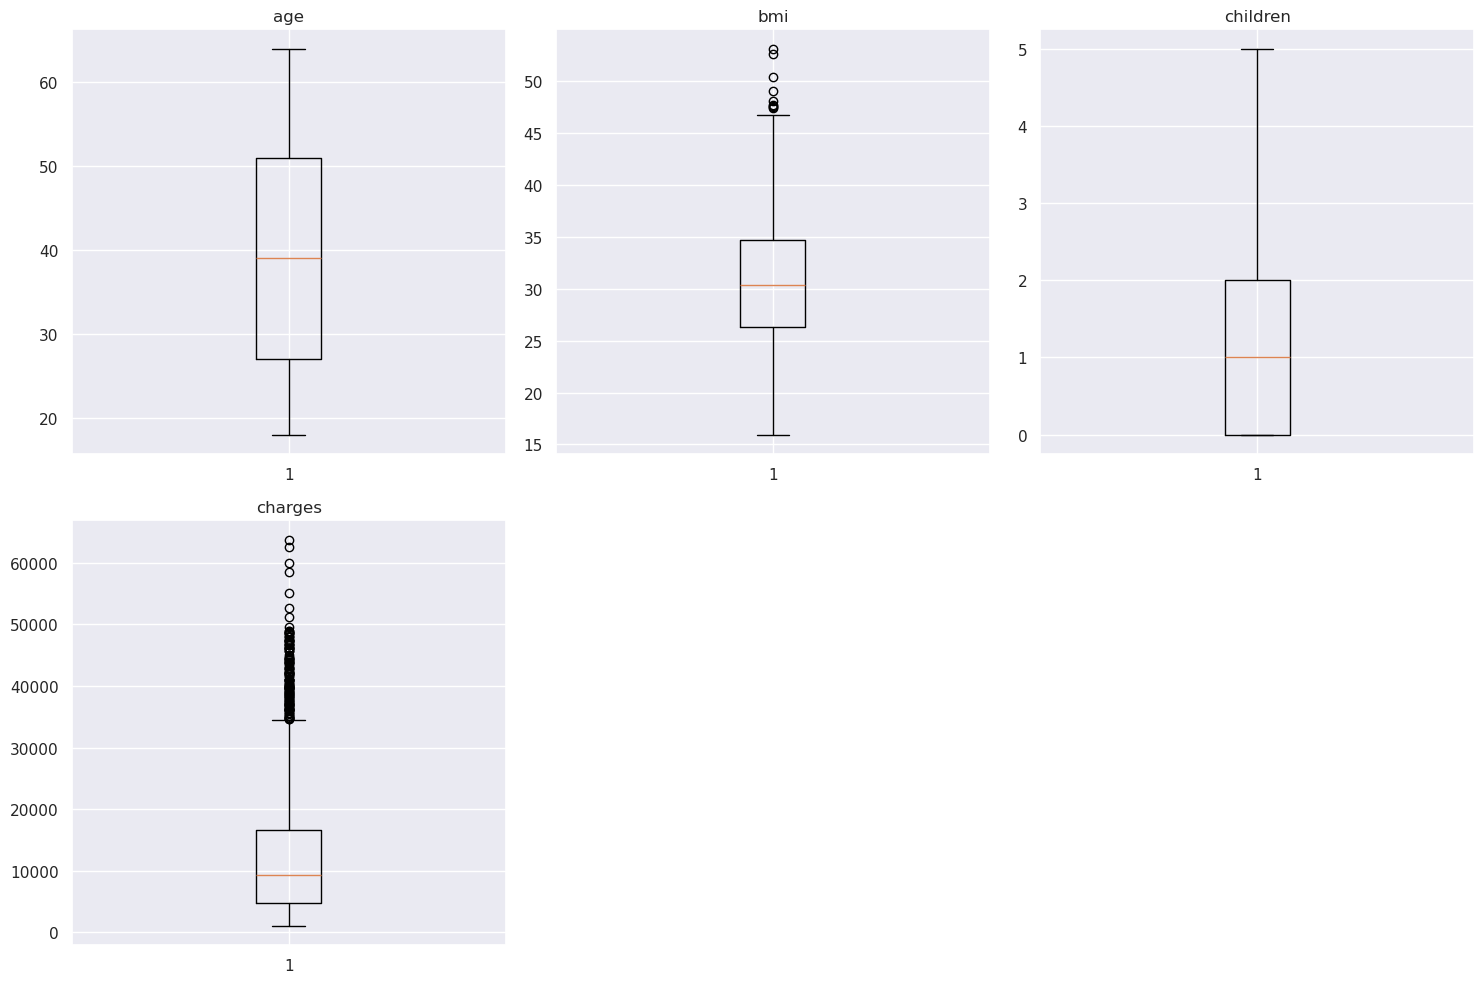

In [30]:
# 4. Boxplots for ALL Numerical Features
import math

n= len(numerical_cols)
cols= 3
rows= math.ceil(n/cols)

plt.figure(figsize=(15,5*rows))

for i,col in enumerate(numerical_cols,1):
    plt.subplot(rows,cols,i)
    plt.boxplot(df_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

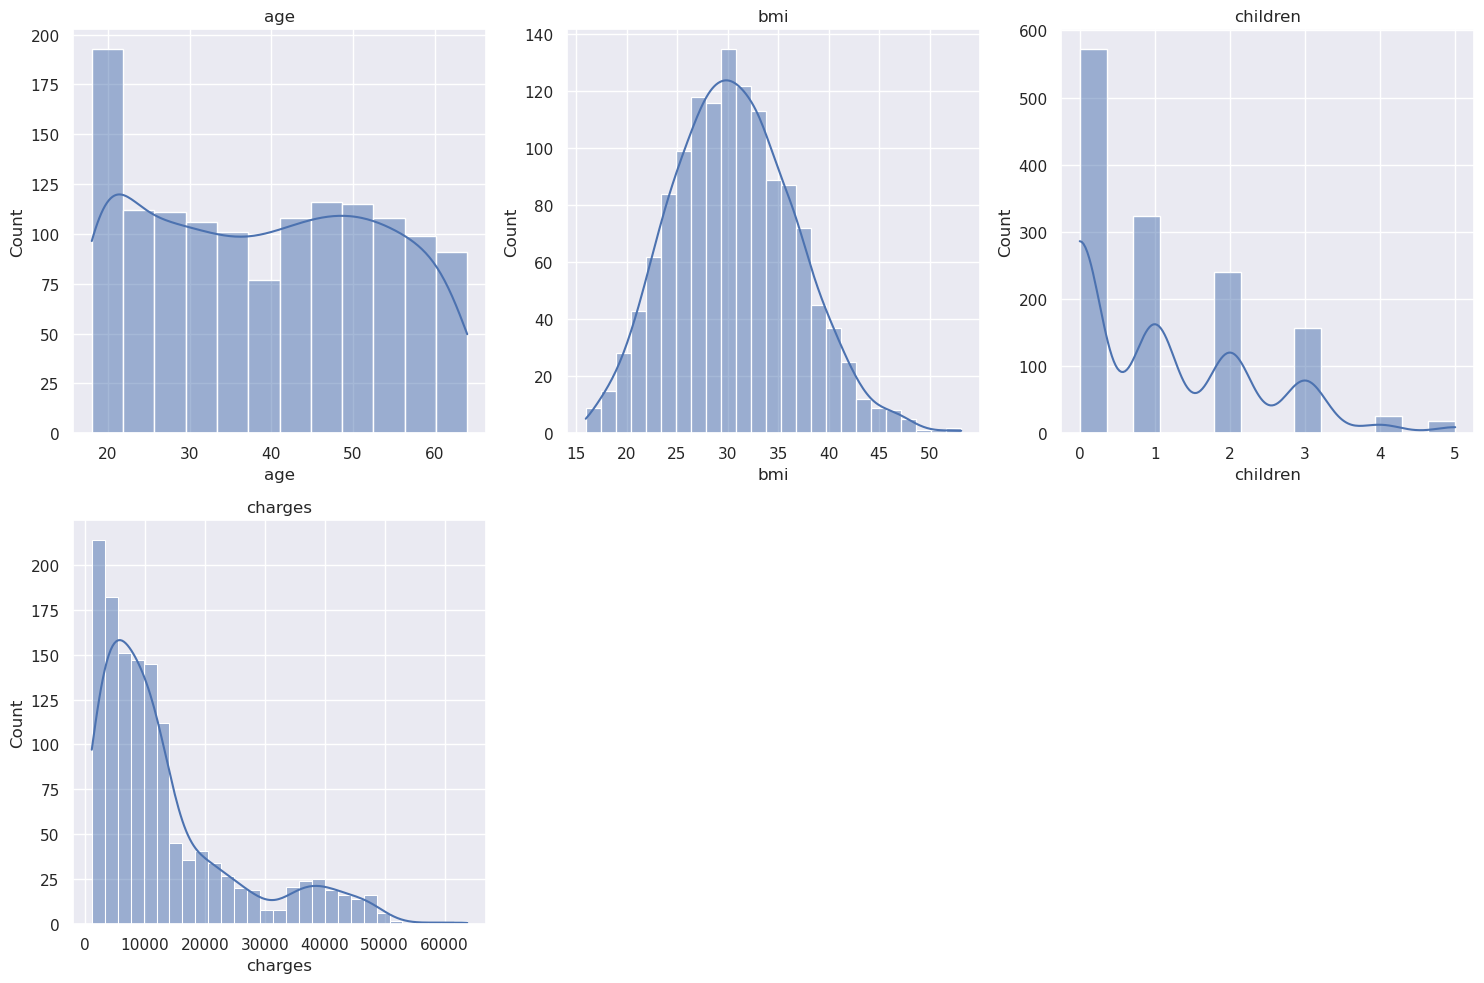

In [31]:
# 5. Distribution Plot (Histogram + KDE) ==> This is even better than histogram.
# Using seaborn
# Kernel Density Estimate (KDE)
plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols,1):
    plt.subplot(rows,cols,i)
    sns.histplot(df_clean[col],kde= True)
    plt.title(col)

plt.tight_layout()
plt.show()

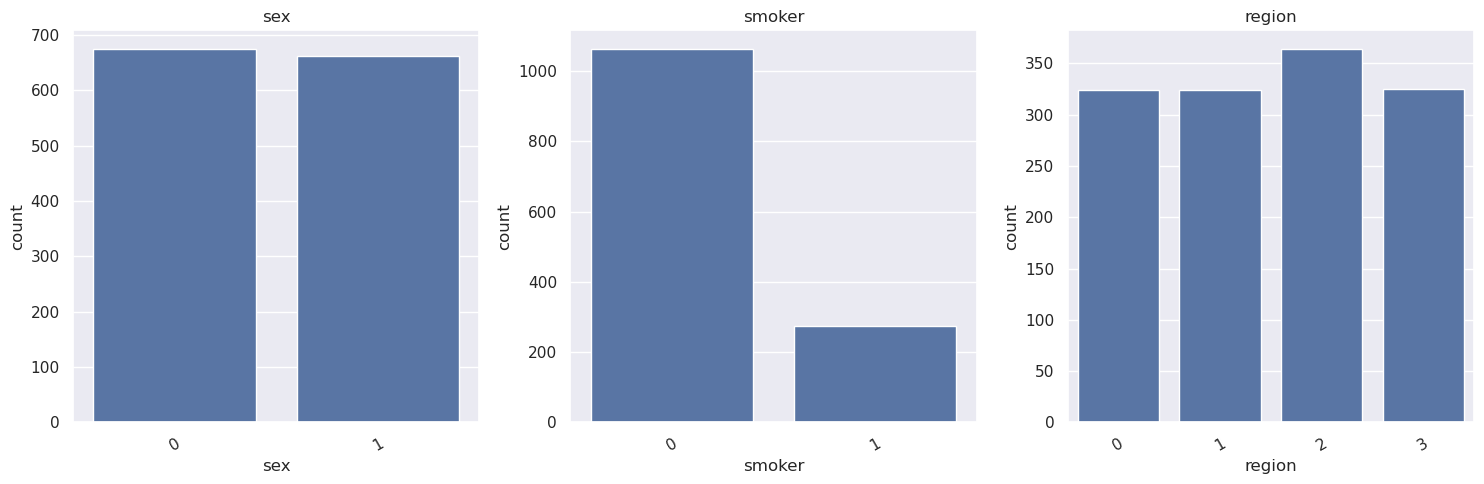

In [32]:
# 6. Count Plot for ALL Categorical Features - (If categorical columns exist)
plt.figure(figsize=(15,5))

for i,col in enumerate(categorical_cols,1):

    plt.subplot(1,len(categorical_cols),i)

    sns.countplot(data=df_clean,x=col)

    plt.xticks(rotation=30)

    plt.title(col)

plt.tight_layout()
plt.show()

In [33]:
# 7. Value Count - For Categorical Cols
for col in categorical_cols:
    print("="*40)
    print(df[col].value_counts())
    print()

sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



In [34]:
# 8. Check Outliers Numerically (IQR)
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3-Q1
    lower = Q1 - 1.5* IQR
    upper = Q3 + 1.5* IQR

    outliers= df_clean[ (df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col:15} -> {len(outliers)} outliers")
    

age             -> 0 outliers
bmi             -> 9 outliers
children        -> 0 outliers
charges         -> 139 outliers


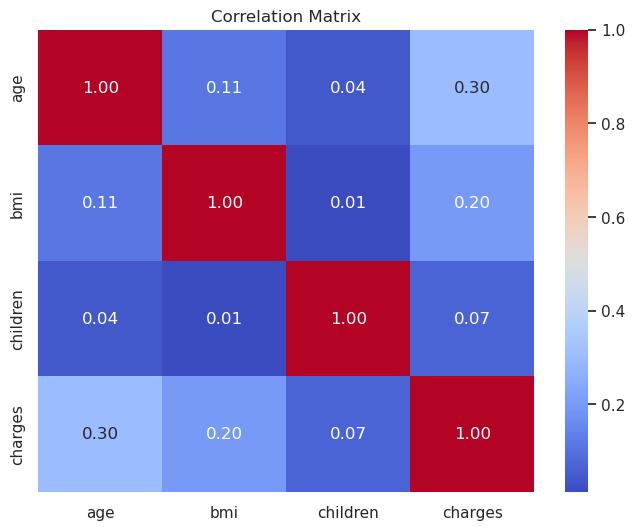

In [35]:
# STEP ===> Bivariate Analysis - 2 Variables relationship with each other
# Bivariate Analysis studies the relationship between two variables.
# Usually, one variable is the target (charges) and the other is a feature.

# 1 : Correlation Matrix
plt.figure(figsize=(8,6))
sns.heatmap(
    df_clean.corr(numeric_only= True),
    annot= True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()


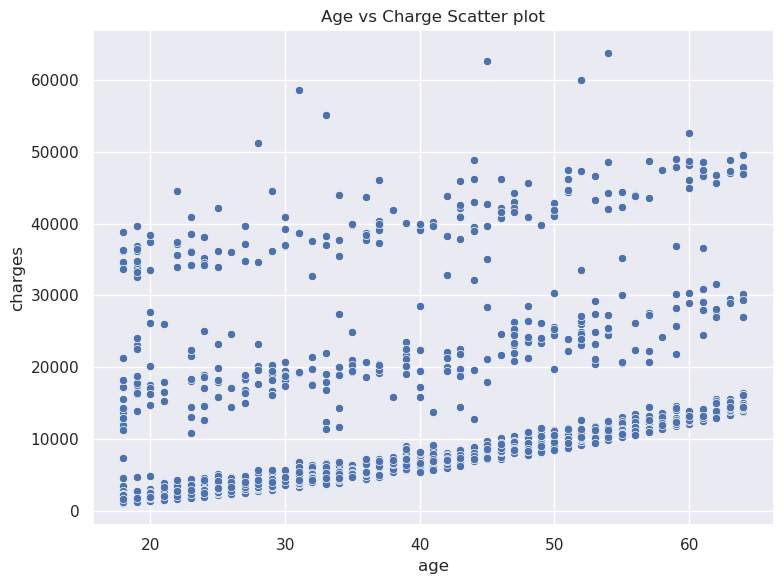

In [36]:
# 2. Scatter Plot (numerical vs numerical)
plt.figure(figsize=(8,6))

sns.scatterplot(
    data= df_clean,
    x="age",
    y="charges"
)
plt.title("Age vs Charge Scatter plot")
plt.tight_layout()
plt.show()

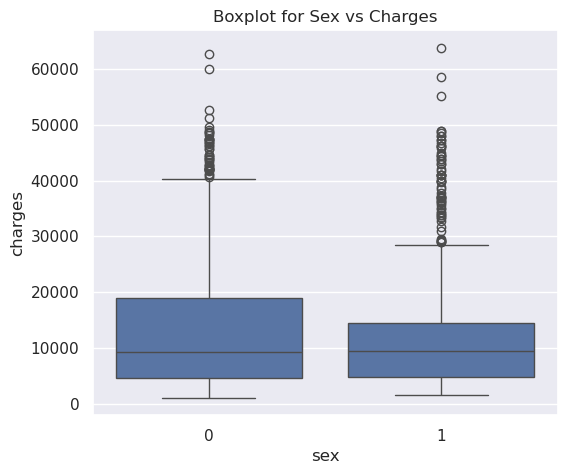

In [37]:
# 3. Box plot for pair of sex and charges (We can do more like this)
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_clean,
    x="sex",
    y="charges"
)

plt.title("Boxplot for Sex vs Charges")
plt.show()

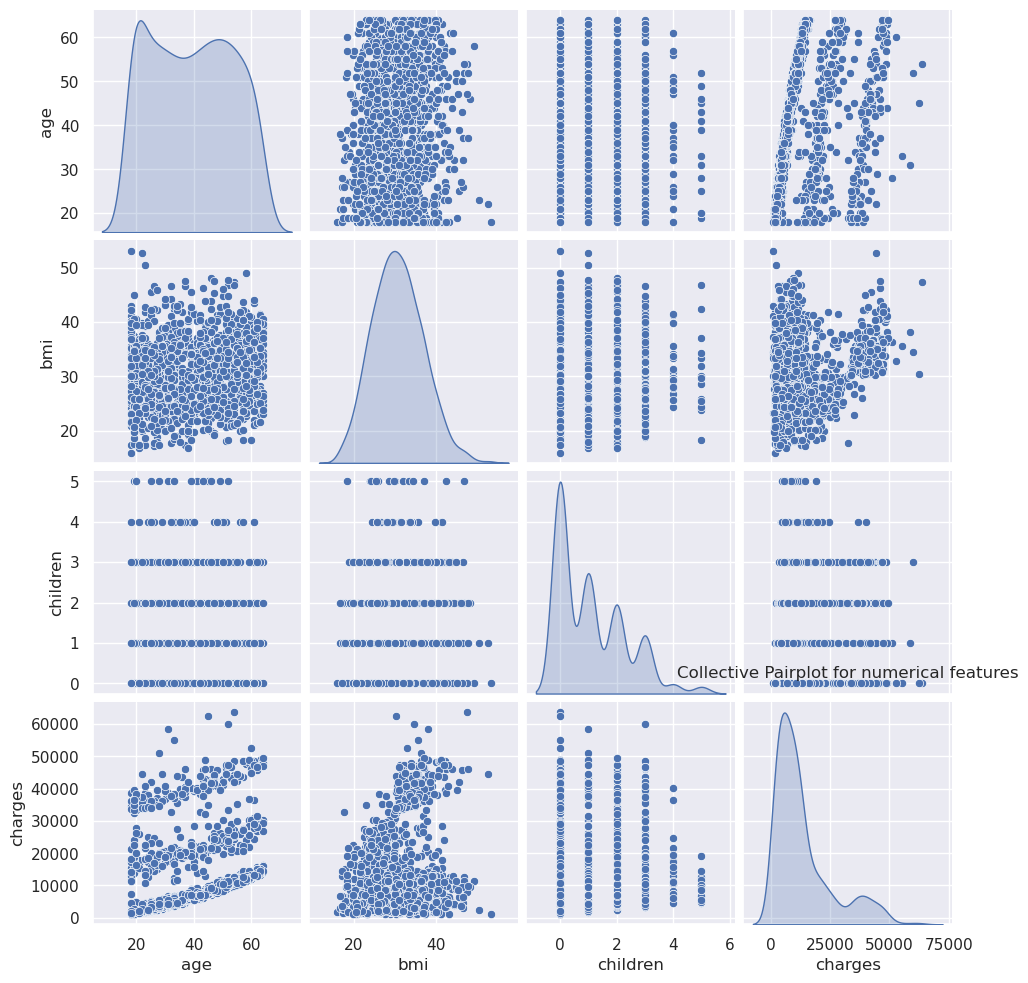

In [38]:
# 4. Collective Scallter Plot for all numerical variables
sns.pairplot(
    df_clean[numerical_cols],
    diag_kind="kde"
)
plt.title("Collective Pairplot for numerical features")
plt.show()

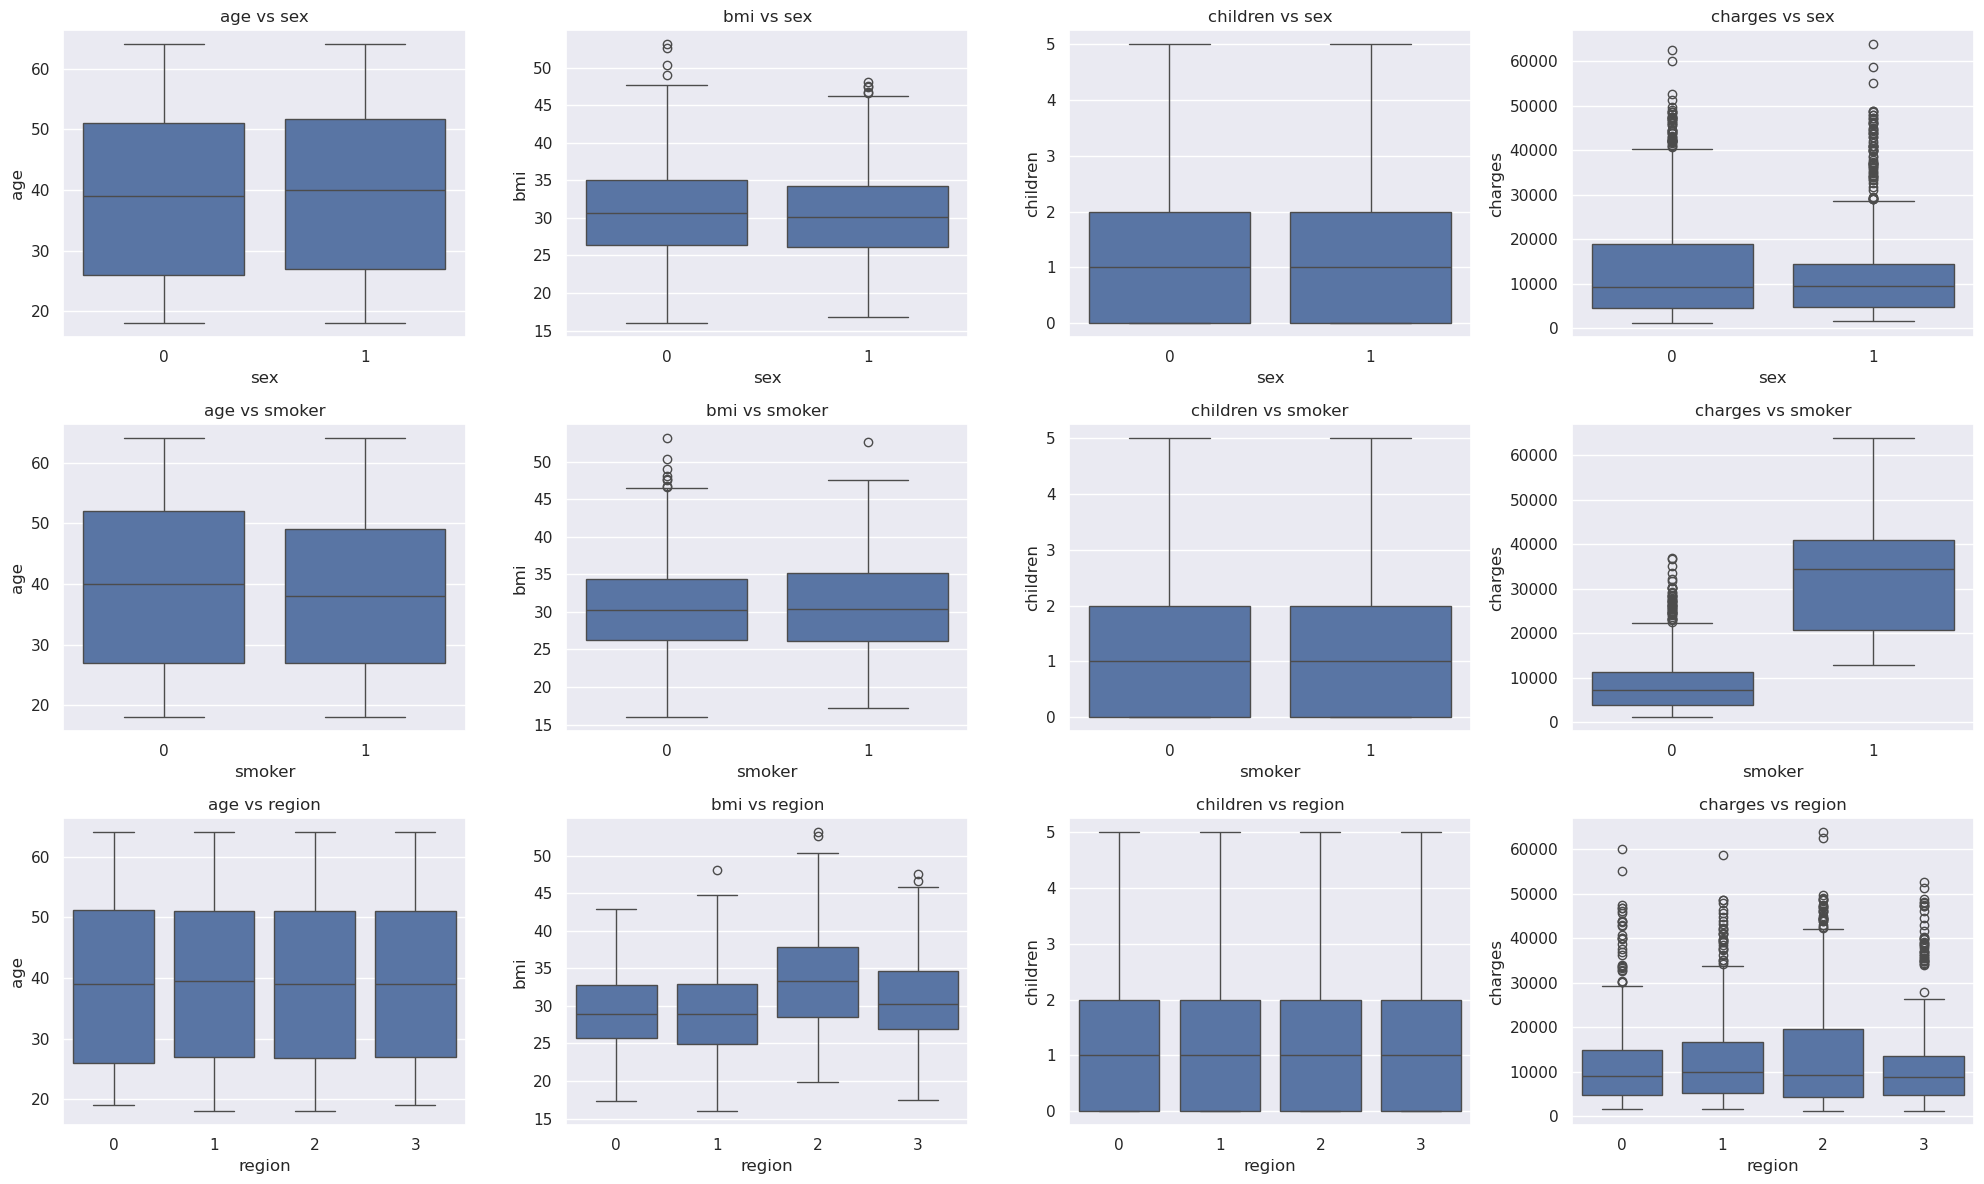

In [39]:
# 5. Collective box plot for all Catergorical vs numerical pairs

rows= len(categorical_cols)
cols= len(numerical_cols)

plt.figure(figsize=(5*cols, 4*rows))
plot_no=1

for cat in categorical_cols:
    for num in numerical_cols:
        plt.subplot(rows,cols,plot_no)
        sns.boxplot(
            data= df_clean,
            x= cat,
            y= num
        )
        plt.title(f"{num} vs {cat}")
        plot_no += 1

plt.tight_layout()
plt.show()

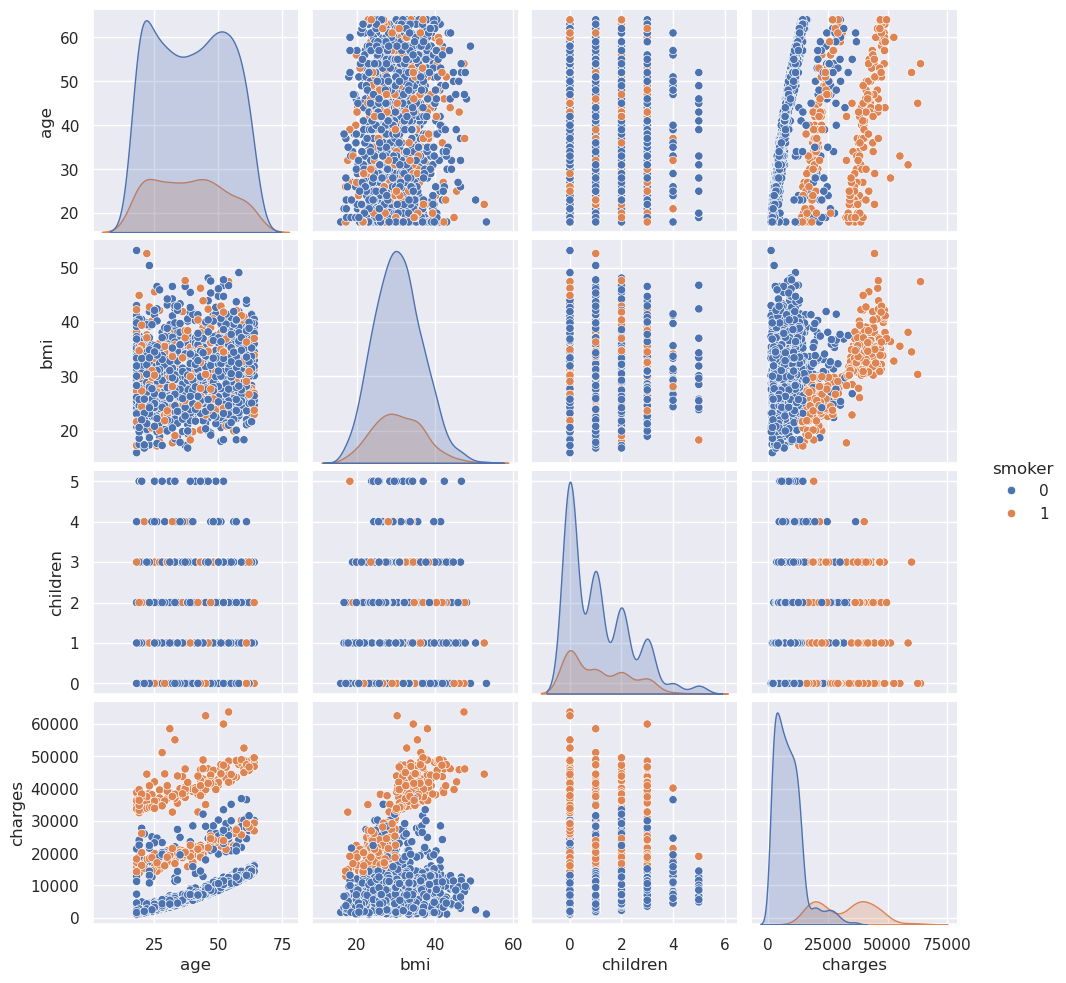

In [40]:
# STEP ===> Mulitvariate Analysis -Sometimes two variables appear unrelated until a third variable is considered.
# So to discover some hidden reln-ships we do Multivariate Analysis
# 1. Pairplot with Hue - This shows every numerical relationship while separating smokers and non-smokers by color.
sns.pairplot(
    df_clean,
    vars = numerical_cols,
    hue = "smoker",
    diag_kind = "kde" # or "hist"
)
plt.show()

<Axes: xlabel='age', ylabel='charges'>

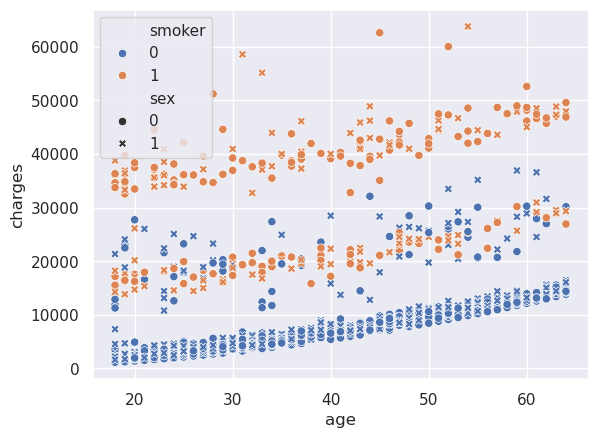

In [41]:
# 2 Scatterplot with Style
sns.scatterplot(
    data=df_clean,
    x="age",
    y="charges",
    hue="smoker", 
    style="sex" # Applyiang Style to differentiate bw A male and a female while taking smoker and non-smoker into consideration
)

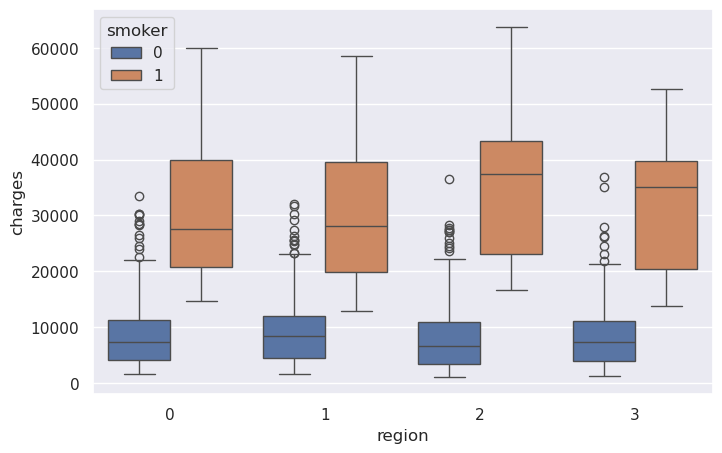

In [42]:
# 3. Box Plot with H
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="region",
    y="charges",
    hue="smoker"
)

plt.show()
#Questions it answers:
# Which region has the highest charges?
# Are smokers more expensive in every region?

In [43]:
# 4. GroupBy Analysis ⭐ - This summarizes how multiple variables jointly affect the target.
df.groupby(["region","smoker","sex"])["charges"].agg(["mean","median","max"])

mean        median          max
region    smoker sex                                            
northeast no     female   9640.426984   8681.137100  31620.00106
                 male     8664.042222   8334.457550  32108.66282
          yes    female  28032.046398  22331.566800  58571.07448
                 male    30926.252583  33993.370025  48549.17835
northwest no     female   8786.998679   7731.857850  33471.97189
                 male     8320.689321   6687.438925  30284.64294
          yes    female  29670.824946  28950.469200  55135.40209
                 male    30713.181419  26109.329050  60021.39897
southeast no     female   8440.205552   7046.722200  36580.28216
                 male     7609.003587   6395.947200  27724.28875
          yes    female  33034.820716  35017.722850  63770.42801
                 male    36029.839367  38282.749500  62592.87309
southwest no     female   8234.091260   7348.142000  36910.60803
                 male     7778.905534   7318.960000  27941.28758
          yes    female  31687.988430  34166.273000  48824.45000
                 male    32598.862854  35585.576000  52590.82939

In [44]:
# STEP ==> Handling Outliers
# : 1. Identify outliers
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower) |
        (df_clean[col] > upper)
    ]

    print(f"{col:10} : {len(outliers)} outliers")

age        : 0 outliers
bmi        : 9 outliers
children   : 0 outliers
charges    : 139 outliers


#2. Decide whether to treat them
Feature	Action
age- 	    Keep
bmi-	    Optional treatment
children-	Keep
charges-	Keep
sex-	    Not applicable
smoker-	    Not applicable
region-	    Not applicable


Why keep the charges outliers?
Ans - Because they are real observations, not data-entry mistakes. Someone can genuinely have a medical bill of ₹60,000 (or equivalent). Removing such values would make the model less representative of real-world insurance costs.

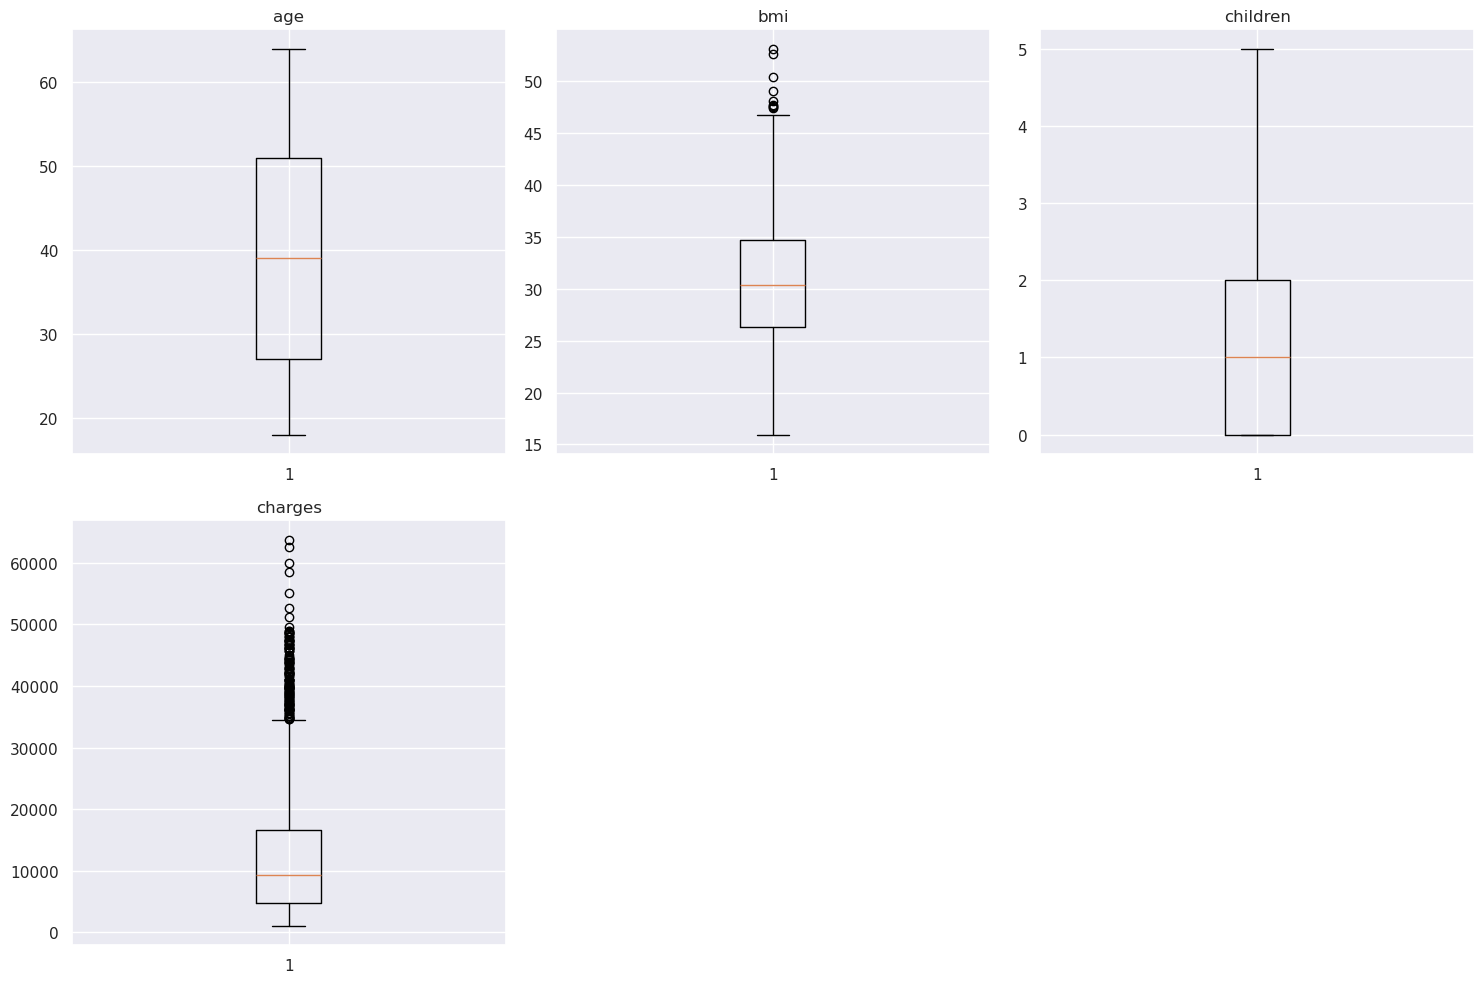

In [45]:
# 3. Visualize before treatment
n= len(numerical_cols)
cols= 3
rows= math.ceil(n/cols)

plt.figure(figsize=(15,5*rows))

for i,col in enumerate(numerical_cols,1):
    plt.subplot(rows,cols,i)
    plt.boxplot(df_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [46]:
# 4. Handle only if necessary
# 4i- Option 1- Remove rows (IQR filtering) - It is not mandatory that we have to do this thing - DO ONLY IF MODEL BENEFITS THIS THING
Q1 = df_clean["bmi"].quantile(0.25)
Q3 = df_clean["bmi"].quantile(0.75)

IQR = Q3-Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR 

df_clean = df_clean[    # Taking taht part which is inside the lower and the upper boundaries and ignoring outer part.
    (df_clean["bmi"] >= lower) &
    (df_clean["bmi"] <= upper)
]

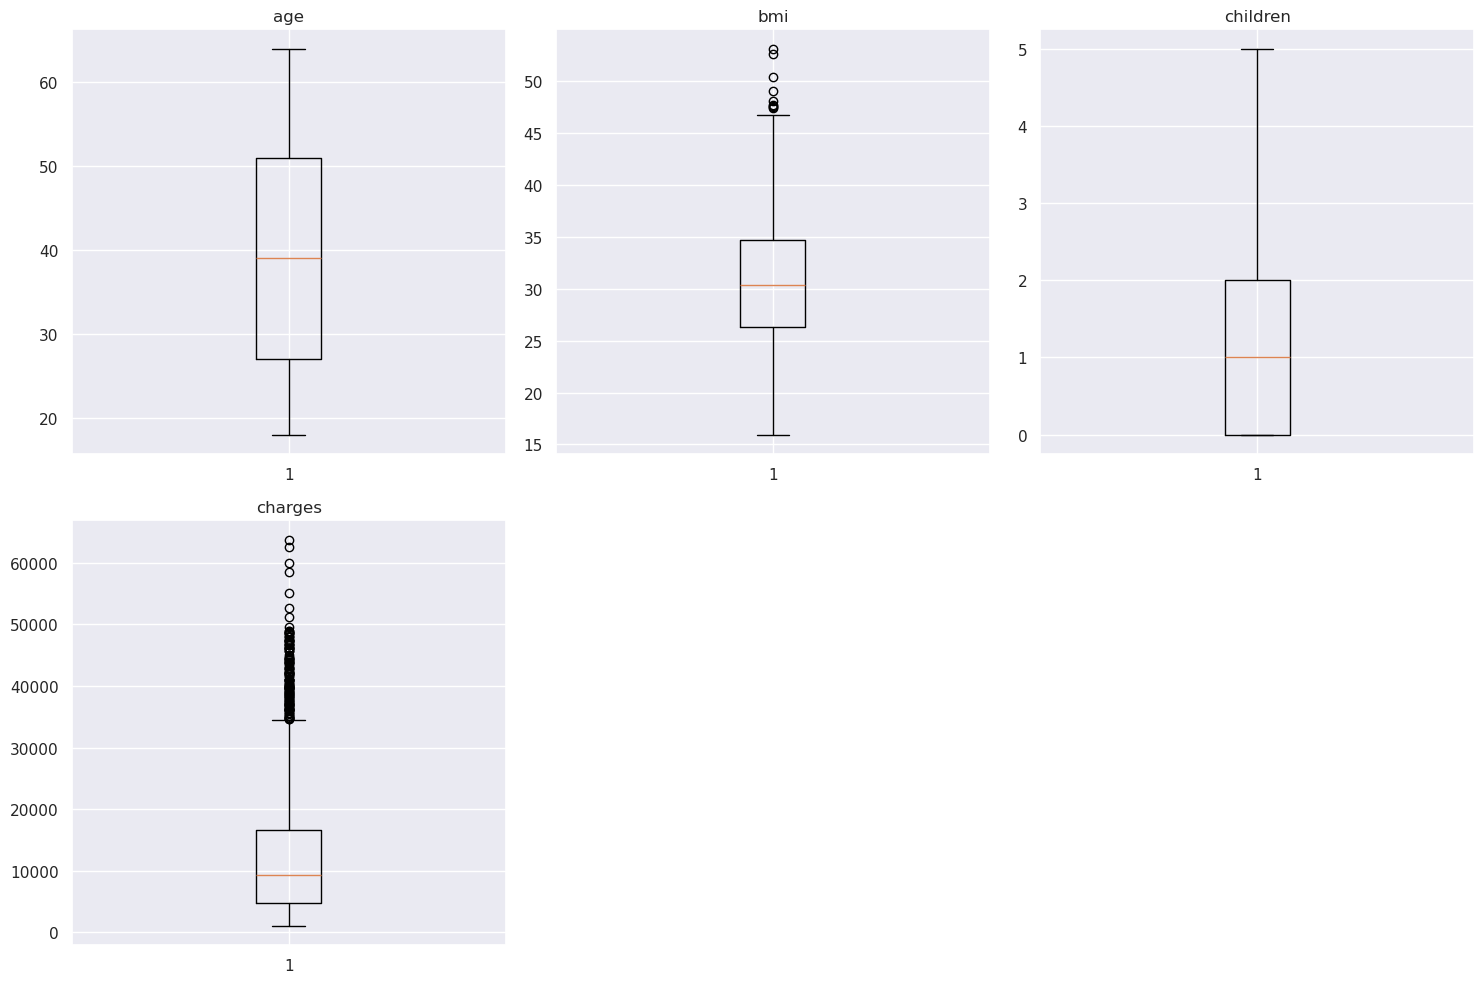

In [54]:
plt.figure(figsize=(15,5*rows))

for i,col in enumerate(numerical_cols,1):
    plt.subplot(rows,cols,i)
    plt.boxplot(df_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [55]:
df_clean = df_clean_copy.copy() # For retrieving the df_clean after IQR filtering changes

4ii - Option 2 - Winsorization (Capping) - Instead of removing observations, cap extreme values.
Instead of throwing away extreme outliers, it forces them to fit into a reasonable range.

Imagine your 99th percentile (upper) is calculated to be a BMI of 48.0.If Patient A has a recorded BMI of 62.0 (a massive outlier), 
the code will overwrite it and change it to 48.0.If Patient B has a normal BMI of 28.0, the code leaves it completely alone as 28.0.

In [56]:
df_clean["bmi"].describe() # Before Changes of BMI Winsorization

count    1337.000000
mean       30.663452
std         6.100468
min        15.960000
25%        26.290000
50%        30.400000
75%        34.700000
max        53.130000
Name: bmi, dtype: float64

In [57]:
# Winsorization
lower = df_clean["bmi"].quantile(0.01)
upper = df_clean["bmi"].quantile(0.99)

print("Lower: ",lower)
print("upper: ",upper)

df_clean["bmi"] = df_clean["bmi"].clip(lower, upper)

df_clean["bmi"].describe() 

Lower:  17.894199999999998
upper:  46.411200000000036


count    1337.000000
mean       30.649787
std         6.027430
min        17.894200
25%        26.290000
50%        30.400000
75%        34.700000
max        46.411200
Name: bmi, dtype: float64

Option 3 - Log Transformation
Useful for highly right-skewed variables like charges.
Log Transformation squishes extreme, highly skewed data values closer together to make the overall distribution look more like a symmetrical bell curve (normal distribution).
This reduces skewness while keeping all observations.

**Golden Rules of Log Transformation**
⚠️ **Rule 1: No Zeros or Negatives.** The logarithm of 0 or negative numbers is mathematically undefined (-inf). If your data contains zeros, you must use np.log1p(df['columns']), which automatically adds 1 to every value before taking the log to prevent errors.
↩️ **Rule 2: You must reverse it for predictions.** If your machine learning model predicts a log-transformed value (e.g., it predicts a charge of 4), you must convert it back to real dollars using an exponential function (np.exp() or 10**x) so humans can understand it (10^4 = $10,000)

✅ Optionally apply a log transformation to charges if the chosen machine learning model benefits from a less skewed target distribution.

In [58]:
# With the help of numpy
df_clean["charges_log"] = np.log1p(df_clean["charges"])

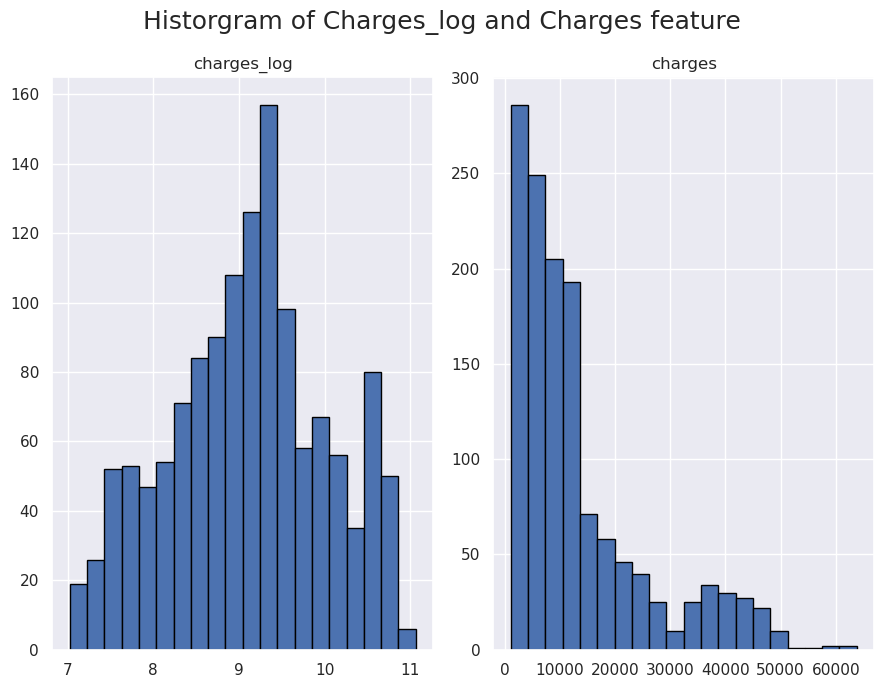

In [59]:
df_clean[["charges_log","charges"]].hist(
    figsize=(9,7),
    bins= 20,
    edgecolor='black'
)
plt.suptitle("Historgram of Charges_log and Charges feature",fontsize=18)
plt.tight_layout()
plt.show()

STEP - Feature Engineering 
-
* No additional feature engineering is required for this dataset.
* The existing features are already meaningful and sufficient for model training.

- Feature Engineering is the process of creating new features or modifying existing features so that the machine learning model can learn better patterns.
- Creating new feature like => BMI_per_Child = bmi / (children + 1)
- Binning Numerical Features
- Combining Columns - First Name + Last Name => Full Name
- etc

In [60]:
#Example of Binning Numerical Feature
df_clean["Age_Group"] = pd.cut(
    df_clean["age"],
    bins=[17,30,45,65],
    labels=["Young","Adult","Senior"]
)
df_clean[['age',"Age_Group"]].head()

,age,Age_Group
0,19,Young
1,18,Young
2,28,Young
3,33,Adult
4,32,Adult


STEP - Feature Encoding
-
* Machine Learning algorithms work with numbers, not text. So, we convert the categories into numbers
* Ex: Male    → 0 Female  → 1

Types of Feature Encoding 
1. Label Encoding - Assigns an integer to each category.
   - Small   → 0,Medium  → 1,Large   → 2
   - When to use - With Binary or Ordinal Categories where there is a natural order
   - Yes/No, Male/Female, True/False, Low/Medium/High
2. One-Hot Encoding ⭐ - Use when: Nominal categorical variables (no order).
    - Ex: City,Region,Department,Color
3. Ordinal Encoding - Categories have a natural order.
4. Target Encoding (Advanced)
    - Use when: High-cardinality categorical columns (many unique values).
    - Ex: City,Product_ID,Zip_Code

In [ ]:
# Example Label Encoding using LabelEncoder
from sklearn.preprocessing import LabelEncoder 
le= LabelEncoder()

df_clean["sex"] = le.fit_transform(df_clean["sex"])

In [ ]:
# Example One-Hot-Encoding using Pandas
df_clean = pd.get_dummies(
    df_clean,
    columns=["Region", "City"],
    drop_first=True,
    dtype=int
)

In [ ]:
# Example Ordinal-Encoding using OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(
    categories=[["Poor", "Average", "Good", "Excellent"]]
)

df["Rating"] = oe.fit_transform(df[["Rating"]])

In [ ]:
# Example Target Encoding  using category_encoders 
from category_encoders import TargetEncoder

te = TargetEncoder()

df["City"] = te.fit_transform(df["City"], y)
# where y is the target variable.

STEP - Feature Scaling (if needed)
-
Feature Scaling is the process of bringing all numerical features to a similar scale.

Example- 
Age ranges from 18–65
Salary ranges from 20,000–1,00,000+
Many ML algorithms consider Salary much more important simply because its values are much larger.

Scaling solves this problem.

Types of Scaling- 
1. StandardScaler ⭐
2. MinMaxScaler
3. RobustScaler

Which scaler should I use?
* Dataset	  ============            Scaler
* Normal distribution	-     StandardScaler
* Deep Learning	     -    MinMaxScaler
* Many Outliers	     -    RobustScaler

In [ ]:
# Example of StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# Example of MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# Example of RobustScaler
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

STEP => Feature Selection (if needed)
-
* Selecting only the useful features and removing unnecessary ones

Usually when there are
- 50+
- 100+
- 500+
- 1000+ Features
- Not usually needed when you only have 5–10 meaningful features, like the insurance dataset.

STEP => Dimensionality Reduction (if needed)
- 
Common Techniques
1. PCA (Principal Component Analysis)
    - Linear
    - Unsupervised
    - Preserves maximum variance
2. LDA (Linear Discriminant Analysis)
    - Supervised
    - Uses target labels
    - Maximizes class separation

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_pca = pca.fit_transform(X_scaled)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda.fit_transform(X, y)

EDA Process Completed Successfully
-